# ANI Regression

## Setup

In [21]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

DATA_FILE = "~/scratch/enterobacteriacea/combined_data.tsv"
K = 7
FCGR_DIM = 2**K * 2**K   # 128 × 128 = 16384
N_COMPONENTS = 500       # number of PCA components

df = pd.read_csv(DATA_FILE, sep="\t")

# Keep only rows with FCGRs available
df = df[(df["fcgr1_exists"]) & (df["fcgr2_exists"])]


## Load fcgrs

In [7]:
genome_paths = {}

for _, row in df.iterrows():
    genome_paths[row["g1"]] = row["fcgr1"]
    genome_paths[row["g2"]] = row["fcgr2"]

print("Unique genomes:", len(genome_paths))

fcgr_cache = {}

def load_fcgr(path):
    M = np.load(path).astype(np.float32)
    M /= (np.linalg.norm(M) + 1e-8)
    return M.flatten()

for g, path in tqdm(genome_paths.items(), desc="Loading FCGRs"):
    fcgr_cache[g] = load_fcgr(path)
    
genomes = list(genome_paths.keys())

X_fcgr = np.vstack([fcgr_cache[g] for g in genomes])
print("Matrix shape:", X_fcgr.shape)


Unique genomes: 992


Loading FCGRs: 100%|██████████| 992/992 [00:00<00:00, 1489.84it/s]

Matrix shape: (992, 16384)


## Run PCA

In [8]:
pca = PCA(n_components=N_COMPONENTS, random_state=42)
Z = pca.fit_transform(X_fcgr)

print("PCA shape:", Z.shape)

PCA shape: (992, 500)


In [9]:
Z_map = {g: Z[i] for i, g in enumerate(genomes)}

In [10]:
X_pairs = []
y_pairs = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Building pairwise PCA differences"):
    z1 = Z_map[row["g1"]]
    z2 = Z_map[row["g2"]]
    dz = z1 - z2
    X_pairs.append(dz)
    y_pairs.append(row["fastani_ANI"] / 100.0)  # normalize ANI


Building pairwise PCA differences: 100%|██████████| 157414/157414 [00:10<00:00, 14779.78it/s]


In [11]:
X_pairs = np.array(X_pairs, dtype=np.float32)
y_pairs = np.array(y_pairs, dtype=np.float32)

print("Regression feature matrix:", X_pairs.shape)

Regression feature matrix: (157414, 500)


## Split train/test data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pairs, y_pairs, test_size=0.2, random_state=42
)

## Run GBR

In [15]:
params = {
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'device': 'cuda',
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train"), (dtest, "test")],
    verbose_eval=50
)

[0]	train-rmse:0.04510	test-rmse:0.04485
[50]	train-rmse:0.00620	test-rmse:0.00648
[100]	train-rmse:0.00336	test-rmse:0.00390
[150]	train-rmse:0.00256	test-rmse:0.00327
[200]	train-rmse:0.00210	test-rmse:0.00295
[250]	train-rmse:0.00181	test-rmse:0.00277
[300]	train-rmse:0.00161	test-rmse:0.00265
[350]	train-rmse:0.00145	test-rmse:0.00257
[400]	train-rmse:0.00133	test-rmse:0.00250
[450]	train-rmse:0.00123	test-rmse:0.00246
[500]	train-rmse:0.00115	test-rmse:0.00242
[550]	train-rmse:0.00107	test-rmse:0.00239
[600]	train-rmse:0.00101	test-rmse:0.00237
[650]	train-rmse:0.00095	test-rmse:0.00234
[700]	train-rmse:0.00090	test-rmse:0.00232
[750]	train-rmse:0.00085	test-rmse:0.00231
[800]	train-rmse:0.00080	test-rmse:0.00230
[850]	train-rmse:0.00076	test-rmse:0.00228
[900]	train-rmse:0.00073	test-rmse:0.00227
[950]	train-rmse:0.00069	test-rmse:0.00227
[999]	train-rmse:0.00066	test-rmse:0.00226


In [16]:
y_pred = model.predict(dtest)

# Back to ANI %
y_pred_ani = y_pred * 100
y_true_ani = y_test * 100

print("R²:", r2_score(y_true_ani, y_pred_ani))
print("MAE:", mean_absolute_error(y_true_ani, y_pred_ani))

R²: 0.9977057576179504
MAE: 0.11655532568693161


## Plot ANI vs predicted

Saved figure to: ../figures/GBR-ANI.png


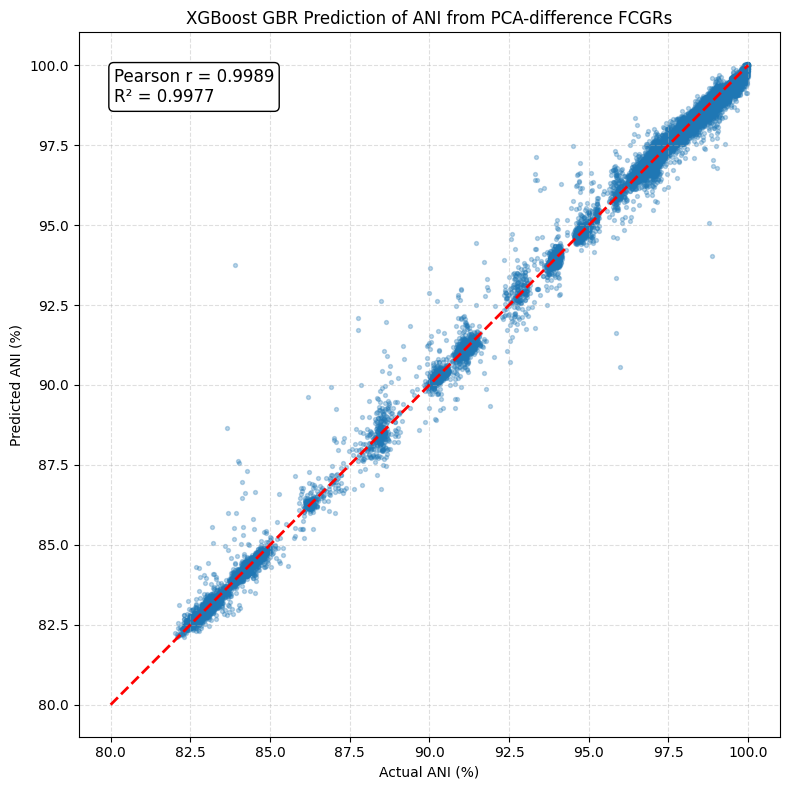

In [17]:
import os
from scipy.stats import pearsonr

pearson_r, _ = pearsonr(y_true_ani, y_pred_ani)
r2 = r2_score(y_true_ani, y_pred_ani)

plt.figure(figsize=(8,8))
plt.scatter(y_true_ani, y_pred_ani, s=8, alpha=0.3)
plt.plot([80,100], [80,100], 'r--', linewidth=2)

plt.xlabel("Actual ANI (%)")
plt.ylabel("Predicted ANI (%)")
plt.title("XGBoost GBR Prediction of ANI from PCA-difference FCGRs")

# Annotation box
textstr = f"Pearson r = {pearson_r:.4f}\nR² = {r2:.4f}"
plt.annotate(
    textstr,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black")
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# SAVE TO THE SPECIFIED PATH
save_path = "../figures/GBR-ANI.png"
plt.savefig(save_path, dpi=300)

print("Saved figure to:", save_path)

plt.show()

## Run linear regression

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

mlr = LinearRegression(n_jobs=-1)   # use all CPU cores

print("Training multi-linear regression model...")
mlr.fit(X_train, y_train)


Training multi-linear regression model...


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = mlr.predict(X_test)

# Convert back to ANI
y_pred_ani = y_pred * 100
y_true_ani = y_test * 100

pearson_r, _ = pearsonr(y_true_ani, y_pred_ani)
r2 = r2_score(y_true_ani, y_pred_ani)
mae = mean_absolute_error(y_true_ani, y_pred_ani)

print("Pearson r:", pearson_r)
print("R²:", r2)
print("MAE:", mae)


Pearson r: 0.39417073
R²: 0.15406107902526855
MAE: 2.9261207580566406


## Plot ANI vs predicted

Saved figure to: ../figures/LR-ANI.png


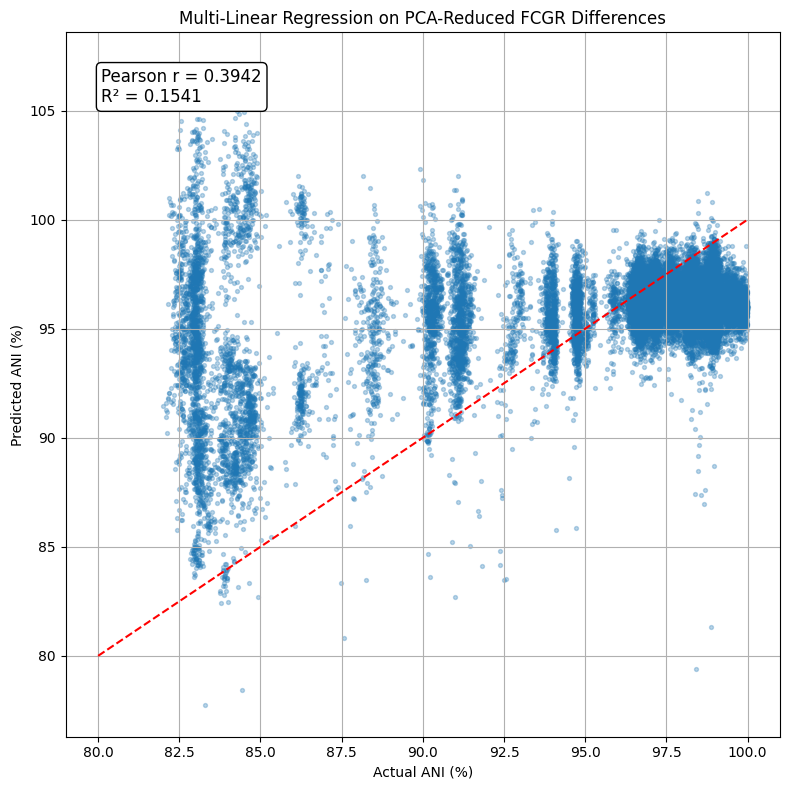

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(y_true_ani, y_pred_ani, s=8, alpha=0.3)
plt.plot([80,100], [80,100], 'r--')

plt.xlabel("Actual ANI (%)")
plt.ylabel("Predicted ANI (%)")
plt.title("Multi-Linear Regression on PCA-Reduced FCGR Differences")

textstr = f"Pearson r = {pearson_r:.4f}\nR² = {r2:.4f}"

plt.annotate(
    textstr,
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    ha='left', va='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black")
)

# SAVE TO THE SPECIFIED PATH
save_path = "../figures/LR-ANI.png"
plt.savefig(save_path, dpi=300)

print("Saved figure to:", save_path)

plt.grid(True)
plt.tight_layout()
plt.show()
